In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Customers (1).csv to Customers (1).csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Orders.csv to Orders.csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Products.csv to Products.csv


In [ ]:
import pandas as pd

orders = pd.read_csv("Orders.csv")
customers = pd.read_csv("Customers (1).csv")
products = pd.read_csv("Products.csv")

print("Orders:")
display(orders.head())

print("Customers:")
display(customers.head())

print("Products:")
display(products.head())

Orders:


,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Price,Discount
0,ORD00001,2025-05-07,CUST0034,PROD0002,3,9364,20
1,ORD00002,2025-05-03,CUST0081,PROD0019,3,3133,15
2,ORD00003,2025-05-27,CUST0092,PROD0025,2,726,10
3,ORD00004,2025-10-04,CUST0041,PROD0011,1,1271,5
4,ORD00005,2025-07-16,CUST0030,PROD0015,2,17205,25


Customers:


,Customer_ID,Name,Age,Gender,City,Signup_Date
0,CUST0001,Customer 1,58,Male,Delhi,2024-10-08
1,CUST0002,Customer 2,33,Male,Bengaluru,2024-04-14
2,CUST0003,Customer 3,52,Male,Lucknow,2025-03-08
3,CUST0004,Customer 4,20,Male,Mumbai,2024-08-11
4,CUST0005,Customer 5,32,Male,Kolkata,2024-07-22


Products:


,Product_ID,Category,Sub_Category,Cost,Selling_Price
0,PROD0001,Fashion,Shoes,1104,2171
1,PROD0002,Home & Kitchen,Furniture,5500,9364
2,PROD0003,Fashion,Shoes,924,2375
3,PROD0004,Fashion,Jeans,804,1268
4,PROD0005,Fashion,Jackets,1342,2921


In [ ]:
print("Orders:", orders.columns.tolist())
print("Customers:", customers.columns.tolist())
print("Products:", products.columns.tolist())

Orders: ['Order_ID', 'Order_Date', 'Customer_ID', 'Product_ID', 'Quantity', 'Price', 'Discount']
Customers: ['Customer_ID', 'Name', 'Age', 'Gender', 'City', 'Signup_Date']
Products: ['Product_ID', 'Category', 'Sub_Category', 'Cost', 'Selling_Price']


In [ ]:
# Calculate Revenue after applying discount

orders['Revenue'] = (
    orders['Quantity']
    * orders['Price']
    * (1 - orders['Discount'] / 100)
)

# Check the result
display(
    orders[
        ['Order_ID', 'Quantity', 'Price', 'Discount', 'Revenue']
    ].head()
)

,Order_ID,Quantity,Price,Discount,Revenue
0,ORD00001,3,9364,20,22473.60
1,ORD00002,3,3133,15,7989.15
2,ORD00003,2,726,10,1306.80
3,ORD00004,1,1271,5,1207.45
4,ORD00005,2,17205,25,25807.50


In [ ]:
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

print(orders['Order_Date'].dtype)

datetime64[ns]


In [ ]:
# Latest order date
latest_date = orders['Order_Date'].max()

# Create RFM table
rfm = orders.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (latest_date - x.max()).days,
    'Order_ID': 'count',
    'Revenue': 'sum'
})

# Rename columns
rfm.rename(columns={
    'Order_Date': 'Recency',
    'Order_ID': 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True)

# Reset index
rfm = rfm.reset_index()

# Display RFM table
display(rfm.head())

,Customer_ID,Recency,Frequency,Monetary
0,CUST0002,125,3,306874.10
1,CUST0003,181,1,1785.60
2,CUST0004,109,3,15702.70
3,CUST0005,25,6,87835.05
4,CUST0006,26,7,101196.55


In [ ]:
# Merge RFM data with Customers table

rfm_customers = rfm.merge(
    customers,
    on='Customer_ID',
    how='left'
)

# Display result
display(rfm_customers.head())

,Customer_ID,Recency,Frequency,Monetary,Name,Age,Gender,City,Signup_Date
0,CUST0002,125,3,306874.10,Customer 2,33,Male,Bengaluru,2024-04-14
1,CUST0003,181,1,1785.60,Customer 3,52,Male,Lucknow,2025-03-08
2,CUST0004,109,3,15702.70,Customer 4,20,Male,Mumbai,2024-08-11
3,CUST0005,25,6,87835.05,Customer 5,32,Male,Kolkata,2024-07-22
4,CUST0006,26,7,101196.55,Customer 6,59,Female,Hyderabad,2025-04-04


In [ ]:
# Merge Orders with Products

orders_products = orders.merge(
    products,
    on='Product_ID',
    how='left'
)

# Display result
display(orders_products.head())

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Price,Discount,Revenue,Category,Sub_Category,Cost,Selling_Price
0,ORD00001,2025-05-07,CUST0034,PROD0002,3,9364,20,22473.60,Home & Kitchen,Furniture,5500,9364
1,ORD00002,2025-05-03,CUST0081,PROD0019,3,3133,15,7989.15,Fashion,Watches,2038,3133
2,ORD00003,2025-05-27,CUST0092,PROD0025,2,726,10,1306.80,Beauty,Hair Care,626,726
3,ORD00004,2025-10-04,CUST0041,PROD0011,1,1271,5,1207.45,Home & Kitchen,Bedsheets,753,1271
4,ORD00005,2025-07-16,CUST0030,PROD0015,2,17205,25,25807.50,Electronics,Mobiles,14129,17205


In [ ]:
# Calculate Profit

orders_products['Profit'] = (
    orders_products['Quantity'] *
    (orders_products['Selling_Price'] - orders_products['Cost'])
)

display(
    orders_products[
        ['Order_ID', 'Product_ID', 'Quantity',
         'Cost', 'Selling_Price', 'Profit']
    ].head()
)

,Order_ID,Product_ID,Quantity,Cost,Selling_Price,Profit
0,ORD00001,PROD0002,3,5500,9364,11592
1,ORD00002,PROD0019,3,2038,3133,3285
2,ORD00003,PROD0025,2,626,726,200
3,ORD00004,PROD0011,1,753,1271,518
4,ORD00005,PROD0015,2,14129,17205,6152


In [ ]:
# Calculate Profit Margin

orders_products['Profit_Margin'] = (
    orders_products['Profit'] /
    (orders_products['Quantity'] * orders_products['Selling_Price'])
) * 100

display(
    orders_products[
        ['Product_ID', 'Profit', 'Profit_Margin']
    ].head()
)

,Product_ID,Profit,Profit_Margin
0,PROD0002,11592,41.264417
1,PROD0019,3285,34.950527
2,PROD0025,200,13.774105
3,PROD0011,518,40.755311
4,PROD0015,6152,17.878524


In [ ]:
print("Orders missing values:")
print(orders.isnull().sum())

print("\nCustomers missing values:")
print(customers.isnull().sum())

print("\nProducts missing values:")
print(products.isnull().sum())

Orders missing values:
Order_ID       0
Order_Date     0
Customer_ID    0
Product_ID     0
Quantity       0
Price          0
Discount       0
Revenue        0
dtype: int64

Customers missing values:
Customer_ID    0
Name           0
Age            0
Gender         0
City           0
Signup_Date    0
dtype: int64

Products missing values:
Product_ID       0
Category         0
Sub_Category     0
Cost             0
Selling_Price    0
dtype: int64


In [ ]:
print("Duplicate Orders:", orders.duplicated().sum())
print("Duplicate Customers:", customers.duplicated().sum())
print("Duplicate Products:", products.duplicated().sum())

Duplicate Orders: 0
Duplicate Customers: 0
Duplicate Products: 0


In [ ]:
import pandas as pd

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Orders.csv to Orders.csv


In [ ]:
uploaded = files.upload()

Saving Customers (1).csv to Customers (1).csv


In [ ]:
uploaded = files.upload()

Saving Products.csv to Products.csv


In [ ]:
import pandas as pd

orders = pd.read_csv("Orders.csv")
customers = pd.read_csv("Customers (1).csv")
products = pd.read_csv("Products.csv")

print("Orders loaded successfully")
print("Customers loaded successfully")
print("Products loaded successfully")

Orders loaded successfully
Customers loaded successfully
Products loaded successfully


In [ ]:
print("Orders:")
display(orders.head())

print("Customers:")
display(customers.head())

print("Products:")
display(products.head())

Orders:


,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Price,Discount
0,ORD00001,2025-05-07,CUST0034,PROD0002,3,9364,20
1,ORD00002,2025-05-03,CUST0081,PROD0019,3,3133,15
2,ORD00003,2025-05-27,CUST0092,PROD0025,2,726,10
3,ORD00004,2025-10-04,CUST0041,PROD0011,1,1271,5
4,ORD00005,2025-07-16,CUST0030,PROD0015,2,17205,25


Customers:


,Customer_ID,Name,Age,Gender,City,Signup_Date
0,CUST0001,Customer 1,58,Male,Delhi,2024-10-08
1,CUST0002,Customer 2,33,Male,Bengaluru,2024-04-14
2,CUST0003,Customer 3,52,Male,Lucknow,2025-03-08
3,CUST0004,Customer 4,20,Male,Mumbai,2024-08-11
4,CUST0005,Customer 5,32,Male,Kolkata,2024-07-22


Products:


,Product_ID,Category,Sub_Category,Cost,Selling_Price
0,PROD0001,Fashion,Shoes,1104,2171
1,PROD0002,Home & Kitchen,Furniture,5500,9364
2,PROD0003,Fashion,Shoes,924,2375
3,PROD0004,Fashion,Jeans,804,1268
4,PROD0005,Fashion,Jackets,1342,2921


In [ ]:
# RFM Table

orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

reference_date = orders['Order_Date'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (reference_date - x.max()).days,
    'Order_ID': 'nunique',
    'Price': 'sum'
}).reset_index()

rfm.columns = [
    'Customer_ID',
    'Recency',
    'Frequency',
    'Monetary'
]

display(rfm.head())

,Customer_ID,Recency,Frequency,Monetary
0,CUST0002,126,3,92862
1,CUST0003,182,1,1984
2,CUST0004,110,3,5390
3,CUST0005,26,6,24098
4,CUST0006,27,7,27889


In [ ]:
# RFM Scores

rfm['Recency_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm['Frequency_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['Monetary_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

display(rfm.head())

,Customer_ID,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score
0,CUST0002,126,3,92862,1,1,5
1,CUST0003,182,1,1984,1,1,1
2,CUST0004,110,3,5390,2,1,1
3,CUST0005,26,6,24098,4,3,3
4,CUST0006,27,7,27889,4,4,4


In [ ]:
# Convert RFM scores into numbers

rfm['Recency_Score'] = rfm['Recency_Score'].astype(int)
rfm['Frequency_Score'] = rfm['Frequency_Score'].astype(int)
rfm['Monetary_Score'] = rfm['Monetary_Score'].astype(int)

# Calculate total RFM Score

rfm['RFM_Score'] = (
    rfm['Recency_Score'] +
    rfm['Frequency_Score'] +
    rfm['Monetary_Score']
)

display(rfm.head())

,Customer_ID,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score
0,CUST0002,126,3,92862,1,1,5,7
1,CUST0003,182,1,1984,1,1,1,3
2,CUST0004,110,3,5390,2,1,1,4
3,CUST0005,26,6,24098,4,3,3,10
4,CUST0006,27,7,27889,4,4,4,12


In [ ]:
# Customer Segmentation

def segment_customer(score):
    if score >= 12:
        return "High Value"
    elif score >= 8:
        return "Medium"
    else:
        return "Low"

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

display(
    rfm[
        ['Customer_ID', 'Recency', 'Frequency',
         'Monetary', 'RFM_Score', 'Segment']
    ].head(10)
)

,Customer_ID,Recency,Frequency,Monetary,RFM_Score,Segment
0,CUST0002,126,3,92862,7,Low
1,CUST0003,182,1,1984,3,Low
2,CUST0004,110,3,5390,4,Low
3,CUST0005,26,6,24098,10,Medium
4,CUST0006,27,7,27889,12,High Value
5,CUST0007,239,3,5388,3,Low
6,CUST0008,96,4,6962,5,Low
7,CUST0009,81,5,35935,9,Medium
8,CUST0010,13,8,27776,14,High Value
9,CUST0011,30,8,52075,14,High Value


Segment
Medium        39
Low           35
High Value    25
Name: count, dtype: int64


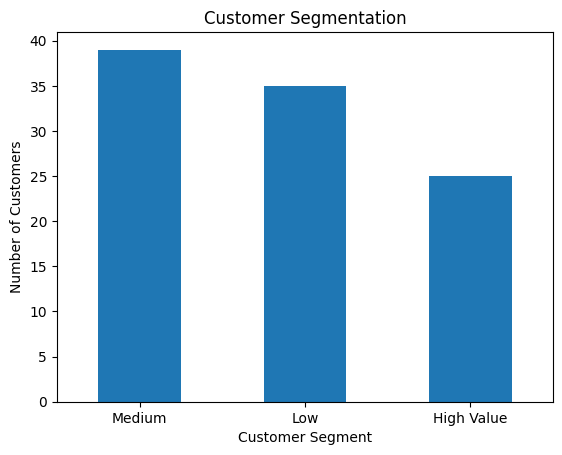

In [ ]:
import matplotlib.pyplot as plt

segment_count = rfm['Segment'].value_counts()

print(segment_count)

segment_count.plot(kind='bar')

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Convert Order_Date to datetime

orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

# Create Order Month

orders['Order_Month'] = orders['Order_Date'].dt.to_period('M')

display(orders[['Customer_ID', 'Order_Date', 'Order_Month']].head())

,Customer_ID,Order_Date,Order_Month
0,CUST0034,2025-05-07,2025-05
1,CUST0081,2025-05-03,2025-05
2,CUST0092,2025-05-27,2025-05
3,CUST0041,2025-10-04,2025-10
4,CUST0030,2025-07-16,2025-07


In [ ]:
# Find each customer's first purchase month

orders['Cohort_Month'] = orders.groupby(
    'Customer_ID'
)['Order_Month'].transform('min')

display(
    orders[
        ['Customer_ID', 'Order_Month', 'Cohort_Month']
    ].head(10)
)

,Customer_ID,Order_Month,Cohort_Month
0,CUST0034,2025-05,2025-05
1,CUST0081,2025-05,2025-05
2,CUST0092,2025-05,2025-02
3,CUST0041,2025-10,2025-03
4,CUST0030,2025-07,2025-02
5,CUST0009,2025-08,2025-03
6,CUST0060,2025-08,2025-03
7,CUST0050,2025-10,2025-04
8,CUST0062,2025-01,2025-01
9,CUST0050,2025-08,2025-04


In [ ]:
# Count unique customers by Cohort Month and Order Month

cohort_data = orders.groupby(
    ['Cohort_Month', 'Order_Month']
)['Customer_ID'].nunique().reset_index()

display(cohort_data.head(10))

,Cohort_Month,Order_Month,Customer_ID
0,2025-01,2025-01,34
1,2025-01,2025-02,9
2,2025-01,2025-03,8
3,2025-01,2025-04,10
4,2025-01,2025-05,10
5,2025-01,2025-06,14
6,2025-01,2025-07,11
7,2025-01,2025-08,11
8,2025-01,2025-09,16
9,2025-01,2025-10,11


In [ ]:
# Create Cohort Table

cohort_table = cohort_data.pivot(
    index='Cohort_Month',
    columns='Order_Month',
    values='Customer_ID'
)

display(cohort_table)

Order_Month,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
Cohort_Month,,,,,,,,,,,,
2025-01,34.0,9.0,8.0,10.0,10.0,14.0,11.0,11.0,16.0,11.0,11.0,10.0
2025-02,NaN,23.0,7.0,6.0,12.0,12.0,11.0,10.0,6.0,6.0,3.0,13.0
2025-03,NaN,NaN,14.0,4.0,6.0,4.0,3.0,6.0,5.0,8.0,8.0,4.0
2025-04,NaN,NaN,NaN,13.0,5.0,6.0,5.0,5.0,4.0,6.0,8.0,2.0
2025-05,NaN,NaN,NaN,NaN,5.0,1.0,1.0,2.0,3.0,2.0,2.0,1.0
2025-06,NaN,NaN,NaN,NaN,NaN,4.0,1.0,NaN,NaN,1.0,2.0,1.0
2025-07,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,NaN,1.0,NaN
2025-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,NaN,NaN
2025-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0


In [ ]:
# Calculate Customer Retention %

retention_table = cohort_table.div(
    cohort_table.iloc[:, 0],
    axis=0
) * 100

display(retention_table.round(2))

Order_Month,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
Cohort_Month,,,,,,,,,,,,
2025-01,100.0,26.47,23.53,29.41,29.41,41.18,32.35,32.35,47.06,32.35,32.35,29.41
2025-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


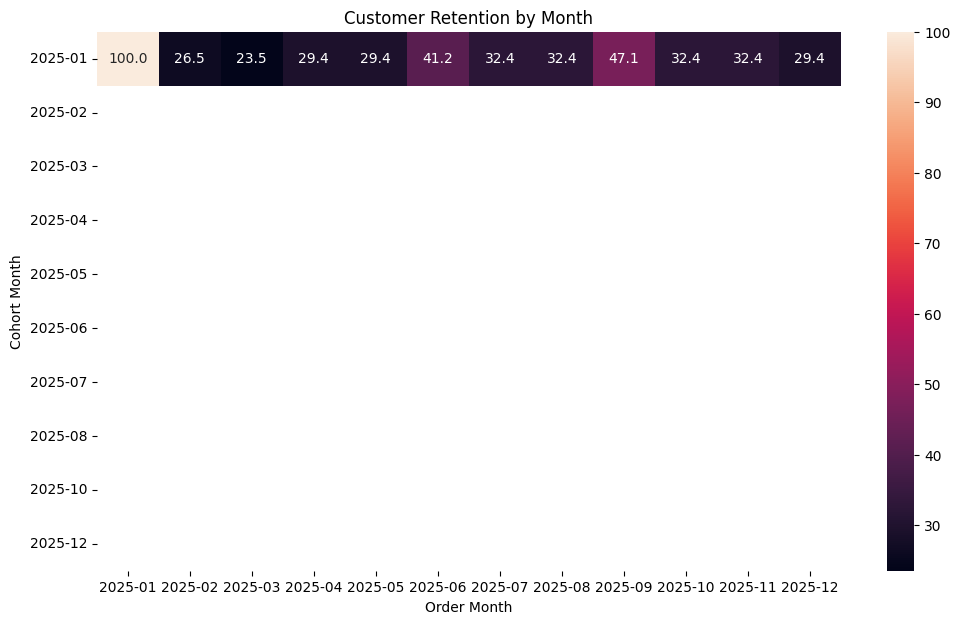

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.heatmap(
    retention_table,
    annot=True,
    fmt='.1f'
)

plt.title("Customer Retention by Month")
plt.xlabel("Order Month")
plt.ylabel("Cohort Month")

plt.show()

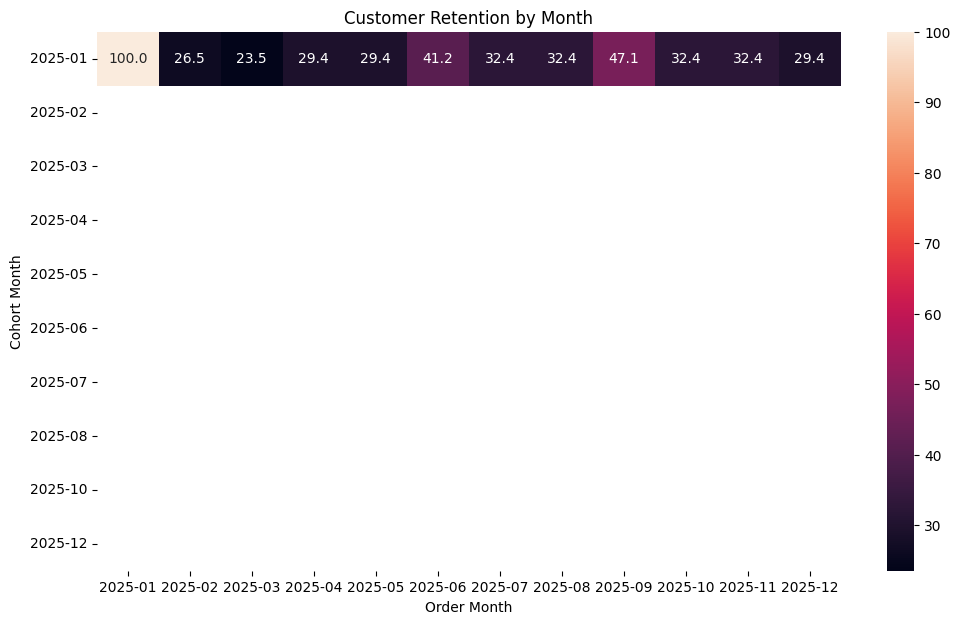

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.heatmap(
    retention_table,
    annot=True,
    fmt='.1f'
)

plt.title("Customer Retention by Month")
plt.xlabel("Order Month")
plt.ylabel("Cohort Month")

plt.show()

In [ ]:
print("Funnel Analysis")
print("Visit → Cart → Purchase")
print()
print("Visit and Cart event data is not available in the current dataset.")
print("Therefore, funnel conversion rates cannot be calculated.")

Funnel Analysis
Visit → Cart → Purchase

Visit and Cart event data is not available in the current dataset.
Therefore, funnel conversion rates cannot be calculated.


In [ ]:
# Purchase Stage

purchase_count = orders['Customer_ID'].nunique()

print("Purchase Customers:", purchase_count)

Purchase Customers: 99


In [1]:
# PHASE 5 - MACHINE LEARNING
# 1. CUSTOMER SEGMENTATION USING K-MEANS

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
from google.colab import files

uploaded = files.upload()

Saving Orders.csv to Orders.csv


In [6]:
from google.colab import files

uploaded = files.upload()

Saving Customers (1).csv to Customers (1).csv


In [7]:
from google.colab import files

uploaded = files.upload()

Saving Products.csv to Products.csv


In [8]:
import pandas as pd

orders = pd.read_csv("Orders.csv")
customers = pd.read_csv("Customers (1).csv")
products = pd.read_csv("Products.csv")

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)

Orders: (500, 7)
Customers: (100, 6)
Products: (50, 5)


In [9]:
display(orders.head())

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Price,Discount
0,ORD00001,2025-05-07,CUST0034,PROD0002,3,9364,20
1,ORD00002,2025-05-03,CUST0081,PROD0019,3,3133,15
2,ORD00003,2025-05-27,CUST0092,PROD0025,2,726,10
3,ORD00004,2025-10-04,CUST0041,PROD0011,1,1271,5
4,ORD00005,2025-07-16,CUST0030,PROD0015,2,17205,25


In [10]:
# PHASE 5 - MACHINE LEARNING
# 1. CUSTOMER SEGMENTATION (K-MEANS)

import pandas as pd

# Convert Order_Date to datetime
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

# Calculate Revenue
orders['Revenue'] = (
    orders['Quantity']
    * orders['Price']
    * (1 - orders['Discount'] / 100)
)

# Reference date
reference_date = orders['Order_Date'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = orders.groupby('Customer_ID').agg(
    Recency=('Order_Date',
             lambda x: (reference_date - x.max()).days),
    Frequency=('Order_ID', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

# Display RFM data
display(rfm.head(10))

,Customer_ID,Recency,Frequency,Monetary
0,CUST0002,126,3,306874.10
1,CUST0003,182,1,1785.60
2,CUST0004,110,3,15702.70
3,CUST0005,26,6,87835.05
4,CUST0006,27,7,101196.55
5,CUST0007,239,3,16105.40
6,CUST0008,96,4,26849.70
7,CUST0009,81,5,108346.20
8,CUST0010,13,8,57619.95
9,CUST0011,30,8,103384.45


In [11]:
# Step 2: Customer Segmentation using K-Means

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Apply K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Create cluster
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Display result
display(rfm.head(10))

,Customer_ID,Recency,Frequency,Monetary,Cluster
0,CUST0002,126,3,306874.10,1
1,CUST0003,182,1,1785.60,0
2,CUST0004,110,3,15702.70,0
3,CUST0005,26,6,87835.05,2
4,CUST0006,27,7,101196.55,2
5,CUST0007,239,3,16105.40,0
6,CUST0008,96,4,26849.70,2
7,CUST0009,81,5,108346.20,2
8,CUST0010,13,8,57619.95,2
9,CUST0011,30,8,103384.45,2


In [12]:
# Step 3: Cluster Summary

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

display(cluster_summary)

,Recency,Frequency,Monetary
Cluster,,,
0,181.72,2.96,43137.37
1,42.27,6.53,223072.13
2,42.47,5.56,60121.89


In [13]:
# Step 4: Assign Customer Segments

# Rank clusters
cluster_summary['Score'] = (
    cluster_summary['Frequency'].rank(ascending=False)
    + cluster_summary['Monetary'].rank(ascending=False)
    + cluster_summary['Recency'].rank(ascending=True)
)

# Best to worst
sorted_clusters = cluster_summary.sort_values(
    'Score',
    ascending=True
).index.tolist()

# Assign names
segment_names = {
    sorted_clusters[0]: 'VIP Customers',
    sorted_clusters[1]: 'Regular Customers',
    sorted_clusters[2]: 'At Risk Customers'
}

rfm['Customer_Segment'] = rfm['Cluster'].map(segment_names)

display(
    rfm[
        [
            'Customer_ID',
            'Recency',
            'Frequency',
            'Monetary',
            'Cluster',
            'Customer_Segment'
        ]
    ].head(20)
)

,Customer_ID,Recency,Frequency,Monetary,Cluster,Customer_Segment
0,CUST0002,126,3,306874.10,1,VIP Customers
1,CUST0003,182,1,1785.60,0,At Risk Customers
2,CUST0004,110,3,15702.70,0,At Risk Customers
3,CUST0005,26,6,87835.05,2,Regular Customers
4,CUST0006,27,7,101196.55,2,Regular Customers
5,CUST0007,239,3,16105.40,0,At Risk Customers
6,CUST0008,96,4,26849.70,2,Regular Customers
7,CUST0009,81,5,108346.20,2,Regular Customers
8,CUST0010,13,8,57619.95,2,Regular Customers
9,CUST0011,30,8,103384.45,2,Regular Customers


In [14]:
# Step 5: Customer Segment Count

segment_count = rfm['Customer_Segment'].value_counts()

display(segment_count)

,count
Customer_Segment,
Regular Customers,59
At Risk Customers,25
VIP Customers,15


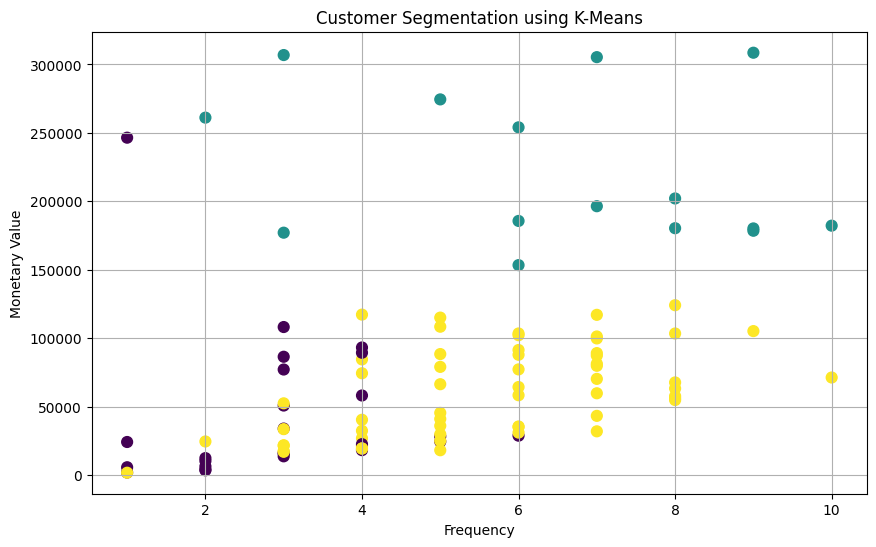

In [15]:
# Step 6: Customer Segmentation Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    s=60
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.grid(True)

plt.show()

In [16]:
# PHASE 5 - MACHINE LEARNING
# 2. SALES FORECASTING (TIME SERIES) - ARIMA

import pandas as pd
import matplotlib.pyplot as plt

# Make sure Order_Date is datetime
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

# Calculate Revenue
orders['Revenue'] = (
    orders['Quantity']
    * orders['Price']
    * (1 - orders['Discount'] / 100)
)

# Create monthly revenue
monthly_revenue = orders.groupby(
    orders['Order_Date'].dt.to_period('M')
)['Revenue'].sum()

# Sort by month
monthly_revenue = monthly_revenue.sort_index()

display(monthly_revenue)

,Revenue
Order_Date,
2025-01,463924.85
2025-02,609533.30
2025-03,533554.10
2025-04,418184.25
2025-05,552217.20
2025-06,811115.50
2025-07,747497.25
2025-08,1077293.85
2025-09,875653.90


In [17]:
from statsmodels.tsa.arima.model import ARIMA

# Create ARIMA model
model = ARIMA(
    monthly_revenue,
    order=(1, 1, 1)
)

# Fit the model
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                   12
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -150.049
Date:                Fri, 11 Sep 2026   AIC                            306.098
Time:                        14:34:37   BIC                            307.292
Sample:                    01-31-2025   HQIC                           305.346
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3091      5.108      0.061      0.952      -9.702      10.321
ma.L1         -0.2242      5.195     -0.043      0.966     -10.407       9.959
sigma2       5.42e+10   7.76e-10   6.99e+19      0.0

In [18]:
# Forecast next 6 months

forecast = model_fit.forecast(steps=6)

print("Sales Forecast for Next 6 Months:")
display(forecast)

Sales Forecast for Next 6 Months:


,predicted_mean
2026-01,300114.713781
2026-02,289396.356682
2026-03,286082.831702
2026-04,285058.472494
2026-05,284741.797113
2026-06,284643.898547


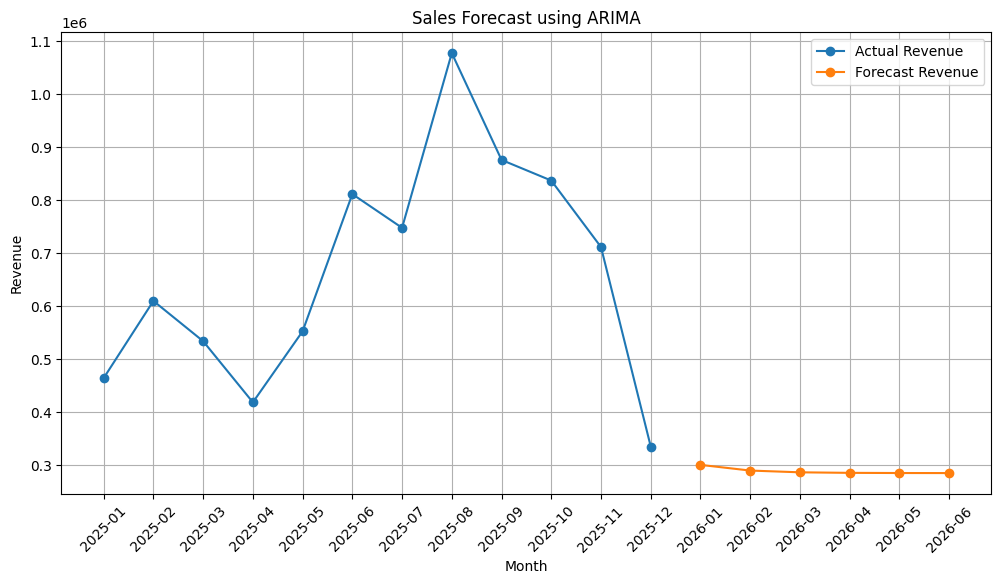

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker='o',
    label='Actual Revenue'
)

future_months = pd.period_range(
    start=monthly_revenue.index[-1] + 1,
    periods=6,
    freq='M'
)

plt.plot(
    future_months.astype(str),
    forecast.values,
    marker='o',
    label='Forecast Revenue'
)

plt.title('Sales Forecast using ARIMA')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [20]:
forecast_df = pd.DataFrame({
    'Month': future_months.astype(str),
    'Forecast_Revenue': forecast.values
})

display(forecast_df)

,Month,Forecast_Revenue
0,2026-01,300114.713781
1,2026-02,289396.356682
2,2026-03,286082.831702
3,2026-04,285058.472494
4,2026-05,284741.797113
5,2026-06,284643.898547


In [21]:
forecast_df.to_csv(
    'ARIMA_Sales_Forecast.csv',
    index=False
)

print("ARIMA Sales Forecast saved successfully!")

ARIMA Sales Forecast saved successfully!


In [22]:
!pip install mlxtend

In [23]:
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
# Create transaction-item matrix

basket = orders.groupby(
    ['Order_ID', 'Product_ID']
)['Quantity'].sum().unstack().fillna(0)

# Convert quantity into 0 and 1
basket = basket.applymap(
    lambda x: 1 if x > 0 else 0
)

display(basket.head())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Product_ID,PROD0001,PROD0002,PROD0003,PROD0004,PROD0005,PROD0006,PROD0007,PROD0008,PROD0009,PROD0010,...,PROD0041,PROD0042,PROD0043,PROD0044,PROD0045,PROD0046,PROD0047,PROD0048,PROD0049,PROD0050
Order_ID,,,,,,,,,,,,,,,,,,,,,
ORD00001,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ORD00002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ORD00003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ORD00004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ORD00005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [25]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

display(
    frequent_itemsets.sort_values(
        'support',
        ascending=False
    ).head(20)
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,support,itemsets
9,0.034,(PROD0016)
14,0.034,(PROD0027)
1,0.030,(PROD0007)
19,0.030,(PROD0038)
22,0.028,(PROD0045)
8,0.028,(PROD0015)
6,0.026,(PROD0013)
21,0.026,(PROD0040)
5,0.026,(PROD0011)
3,0.026,(PROD0009)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [26]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.3
)

display(rules.head(20))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [27]:
recommendation_rules = rules[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].sort_values(
    'lift',
    ascending=False
)

display(recommendation_rules.head(20))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [28]:
def convert_items(items):
    return ', '.join(str(item) for item in items)

recommendation_rules['Buy_Product'] = (
    recommendation_rules['antecedents']
    .apply(convert_items)
)

recommendation_rules['Recommend_Product'] = (
    recommendation_rules['consequents']
    .apply(convert_items)
)

final_recommendations = recommendation_rules[
    [
        'Buy_Product',
        'Recommend_Product',
        'support',
        'confidence',
        'lift'
    ]
]

display(final_recommendations.head(20))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Buy_Product,Recommend_Product,support,confidence,lift


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [29]:
print("Top Product Recommendations:\n")

for _, row in final_recommendations.head(10).iterrows():
    print(
        f"Customers who buy {row['Buy_Product']} "
        f"may also buy {row['Recommend_Product']} "
        f"(Confidence: {row['confidence']:.2%}, "
        f"Lift: {row['lift']:.2f})"
    )

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Top Product Recommendations:



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [30]:
final_recommendations.to_csv(
    'Product_Recommendations.csv',
    index=False
)

print("Product Recommendations saved successfully!")

Product Recommendations saved successfully!


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag